##### Imports

In [16]:
import pandas as pd
from scipy.stats import chisquare
import numpy as np
import matplotlib.pyplot as plt

##### Loading Data

In [17]:
# Notebook is in analysis/, CSV is in data/
df = pd.read_csv("../data/wingo_sorted_with_timestamp.csv")

print(df.columns)
print(df.count())

print(df.head())

Index(['period', 'number', 'color', 'timestamp'], dtype='str')
period       34470
number       34470
color        34470
timestamp    34470
dtype: int64
              period  number         color             timestamp
0  20250331100052012       0  red / violet  2025-03-31T16:45:30Z
1  20250331100052013       3         green  2025-03-31T16:46:00Z
2  20250331100052014       4           red  2025-03-31T16:46:30Z
3  20250331100052015       0  red / violet  2025-03-31T16:47:00Z
4  20250331100052016       4           red  2025-03-31T16:47:30Z


##### Uniformity Test

In [18]:
# Count how many times each number (0-9) appeared
observed_counts = df['number'].value_counts().sort_index()

# The expected count is perfectly even across all 10 numbers
expected_count = len(df) / 10
expected_counts = [expected_count] * 10

# Run the Chi-Square test
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-Value: {p_value:.5f}")

Chi-Square Statistic: 10.08
P-Value: 0.34409


##### Streak Anomaly Check

--- RED STREAK ANOMALY ANALYSIS ---
               Actual_Count  Expected_Count      Diff_%
Streak_Length                                          
1                      4317          4308.8    0.190308
2                      2190          2154.4    1.652432
3                      1105          1077.2    2.580765
4                       547           538.6    1.559599
5                       291           269.3    8.057928
6                       147           134.6    9.212481
7                        52            67.3  -22.734027
8                        29            33.7  -13.946588
9                        14            16.8  -16.666667
10                        6             8.4  -28.571429
11                        4             4.2   -4.761905
12                        1             2.1  -52.380952
13                        1             1.1   -9.090909
14                        1             0.5  100.000000


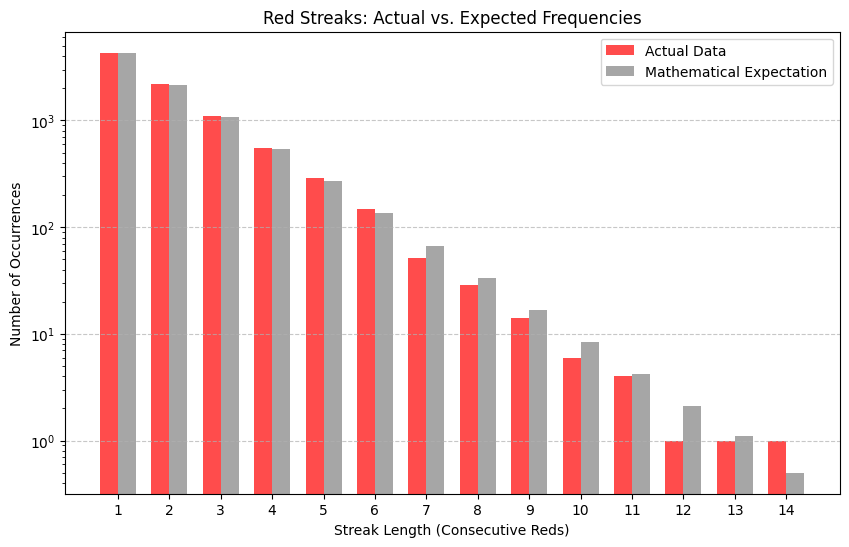

In [19]:
# 1. Define what constitutes a "Red" win (0, 2, 4, 6, 8)
is_red = df['number'].isin([0, 2, 4, 6, 8])
is_green = ~is_red

# 2. Identify streaks
# This creates a new unique ID every time the sequence changes (e.g., Red to Green)
streak_ids = (is_red != is_red.shift()).cumsum()

# 3. Calculate the length of every single streak
# Group by the IDs, sum the boolean values (True = 1), and filter out the Green streaks (0s)
streak_lengths = is_red.groupby(streak_ids).sum()
red_streaks = streak_lengths[streak_lengths > 0].astype(int)

# 4. Count the actual occurrences of each streak length (1 in a row, 2 in a row, etc.)
actual_counts = red_streaks.value_counts().sort_index()

# 5. Calculate the mathematically Expected counts
total_draws = len(df)
p_red = 0.50 # Probability of any Red

expected_counts = []
streak_indices = actual_counts.index

for k in streak_indices:
    # Formula for expected streaks of exactly length k in N trials: N * p^k * (1-p)^2
    expected = total_draws * (p_red**k) * ((1 - p_red)**2)
    expected_counts.append(expected)

# 6. Combine into a clean DataFrame for analysis
comparison_df = pd.DataFrame({
    'Streak_Length': streak_indices,
    'Actual_Count': actual_counts.values,
    'Expected_Count': np.round(expected_counts, 1)
}).set_index('Streak_Length')

# Calculate the percentage difference
comparison_df['Diff_%'] = ((comparison_df['Actual_Count'] - comparison_df['Expected_Count']) / comparison_df['Expected_Count']) * 100

print("--- RED STREAK ANOMALY ANALYSIS ---")
print(comparison_df.to_string())

# 7. Plot the results for visual inspection
plt.figure(figsize=(10, 6))
width = 0.35
x = np.arange(len(comparison_df.index))

plt.bar(x - width/2, comparison_df['Actual_Count'], width, label='Actual Data', color='red', alpha=0.7)
plt.bar(x + width/2, comparison_df['Expected_Count'], width, label='Mathematical Expectation', color='gray', alpha=0.7)

plt.title('Red Streaks: Actual vs. Expected Frequencies')
plt.xlabel('Streak Length (Consecutive Reds)')
plt.ylabel('Number of Occurrences')
plt.xticks(x, comparison_df.index)
plt.yscale('log') # Log scale makes it easier to see the rare long streaks
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Time-Series Profiling

--- HOURLY FREQUENCY OF 0 & 5 ---
hour
0     20.83
1     21.18
2     19.93
3     21.11
4     17.50
5     20.00
6     21.11
7     18.96
8     18.75
9     19.44
10    20.42
11    19.03
12    19.38
13    18.33
14    20.14
15    18.68
16    20.22
17    19.86
18    19.93
19    18.19
20    19.65
21    20.76
22    20.35
23    20.69


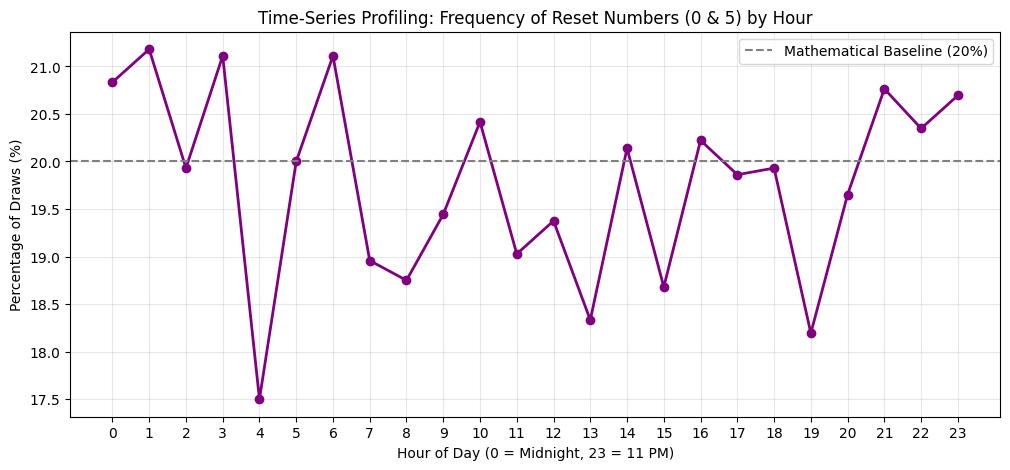

In [20]:
# Assuming your dataframe 'df' has 'timestamp' and 'number' columns
# Ensure timestamp is a datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract the hour (0-23)
df['hour'] = df['timestamp'].dt.hour

# Calculate total draws per hour
hourly_total = df.groupby('hour').size()

# Calculate how many times 0 or 5 hit per hour
hourly_resets = df[df['number'].isin([0, 5])].groupby('hour').size()

# Calculate the percentage
reset_frequency = (hourly_resets / hourly_total) * 100

# Print the raw data
print("--- HOURLY FREQUENCY OF 0 & 5 ---")
print(reset_frequency.round(2).to_string())

# Plot the curve
plt.figure(figsize=(12, 5))
plt.plot(reset_frequency.index, reset_frequency.values, marker='o', linestyle='-', color='purple', linewidth=2)
plt.axhline(y=20, color='gray', linestyle='--', label='Mathematical Baseline (20%)')
plt.title('Time-Series Profiling: Frequency of Reset Numbers (0 & 5) by Hour')
plt.xlabel('Hour of Day (0 = Midnight, 23 = 11 PM)')
plt.ylabel('Percentage of Draws (%)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

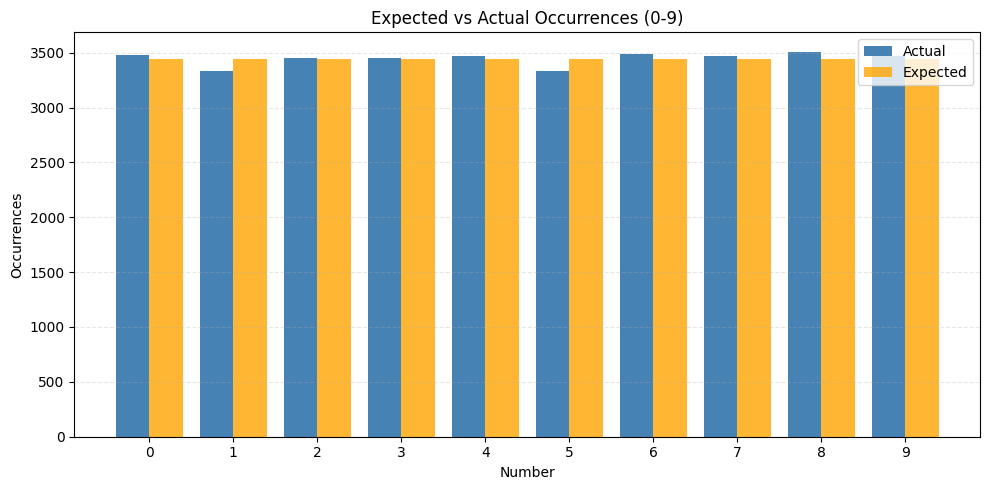

In [21]:
# Actual counts for each number 0-9
actual_num_counts = observed_counts.reindex(range(10), fill_value=0)

# Expected counts (uniform distribution)
expected_num_counts = pd.Series([expected_count] * 10, index=range(10))

# Plot: expected vs actual
plt.figure(figsize=(10, 5))
bar_width = 0.4
idx = np.arange(10)

plt.bar(idx - bar_width/2, actual_num_counts.values, width=bar_width, label="Actual", color="steelblue")
plt.bar(idx + bar_width/2, expected_num_counts.values, width=bar_width, label="Expected", color="orange", alpha=0.8)

plt.xticks(idx, range(10))
plt.xlabel("Number")
plt.ylabel("Occurrences")
plt.title("Expected vs Actual Occurrences (0-9)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()